In [1]:
from inspect import FrameInfo
from google.colab import drive
drive.mount('/content/drive')

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np
import seaborn as sns
import requests
import pprint
import warnings
warnings.filterwarnings('ignore')

font_path = '/content/drive/MyDrive/kwukdt/data-analysis/seoul-bicycle-analysis/data/fonts/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
mpl.rc('font', family = 'NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

Mounted at /content/drive


In [8]:
from datetime import datetime

t1 = datetime.now()
print('현재 시각:', t1)

t2 = datetime(2020, 1, 2, 9, 0, 0)
print('삼성전자 데이터 시작일:', t2)

diff = t1 - t2
print('경과 시간:', diff.days)
print('자료형:', type(diff))

현재 시각: 2026-03-19 07:46:43.352706
삼성전자 데이터 시작일: 2020-01-02 09:00:00
경과 시간: 2267
자료형: <class 'datetime.timedelta'>


In [9]:
DATA_PATH = '/content/drive/MyDrive/kwukdt/data-analysis/data-visualization/samsung_stock.csv'

In [14]:
df = pd.read_csv(DATA_PATH)
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1304 entries, 0 to 1303
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    1304 non-null   object
 1   Open    1304 non-null   int64 
 2   High    1304 non-null   int64 
 3   Low     1304 non-null   int64 
 4   Close   1304 non-null   int64 
 5   Volume  1304 non-null   int64 
dtypes: int64(5), object(1)
memory usage: 61.3+ KB


In [20]:
df['date_dt'] = pd.to_datetime(df['Date'])
df['date_fmt'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')
df['date_yf'] = pd.to_datetime(df['Date'], yearfirst=True)
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1304 entries, 0 to 1303
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      1304 non-null   object        
 1   Open      1304 non-null   int64         
 2   High      1304 non-null   int64         
 3   Low       1304 non-null   int64         
 4   Close     1304 non-null   int64         
 5   Volume    1304 non-null   int64         
 6   date_dt   1304 non-null   datetime64[ns]
 7   date_fmt  1304 non-null   datetime64[ns]
 8   date_yf   1304 non-null   datetime64[ns]
dtypes: datetime64[ns](3), int64(5), object(1)
memory usage: 91.8+ KB


In [22]:
df = pd.read_csv(DATA_PATH, parse_dates=['Date'])
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1304 entries, 0 to 1303
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1304 non-null   datetime64[ns]
 1   Open    1304 non-null   int64         
 2   High    1304 non-null   int64         
 3   Low     1304 non-null   int64         
 4   Close   1304 non-null   int64         
 5   Volume  1304 non-null   int64         
dtypes: datetime64[ns](1), int64(5)
memory usage: 61.3 KB


In [23]:
ts = pd.to_datetime('2026-03-19')
print('Timestamp:', ts)

Timestamp: 2026-03-19 00:00:00


In [27]:
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['weekday'] = df['Date'].dt.weekday
df['quarter'] = df['Date'].dt.quarter
df['dayofyear'] = df['Date'].dt.dayofyear

In [28]:
df[['Date', 'year', 'month', 'day', 'weekday', 'quarter', 'dayofyear']].head()

,Date,year,month,day,weekday,quarter,dayofyear
0,2020-01-02,2020,1,2,3,1,2
1,2020-01-03,2020,1,3,4,1,3
2,2020-01-06,2020,1,6,0,1,6
3,2020-01-07,2020,1,7,1,1,7
4,2020-01-08,2020,1,8,2,1,8


In [29]:
%pip install yfinance -q
import yfinance as yf
df = yf.download('005930.KS', start='2020-01-01')
df.tail()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,005930.KS,005930.KS,005930.KS,005930.KS,005930.KS
Date,,,,,
2026-03-13,183500.0,186200.0,179900.0,180000.0,19566331
2026-03-16,188700.0,189000.0,183600.0,184600.0,19747901
2026-03-17,193900.0,198000.0,193100.0,198000.0,20300082
2026-03-18,208500.0,209000.0,199700.0,200500.0,25148481
2026-03-19,200500.0,205000.0,199600.0,199900.0,18923499


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1521 entries, 2020-01-02 to 2026-03-19
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   (Close, 005930.KS)   1521 non-null   float64
 1   (High, 005930.KS)    1521 non-null   float64
 2   (Low, 005930.KS)     1521 non-null   float64
 3   (Open, 005930.KS)    1521 non-null   float64
 4   (Volume, 005930.KS)  1521 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 71.3 KB


In [32]:
df_f = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

if isinstance(df_f.columns, pd.MultiIndex):
  df_f.columns = df_f.columns.droplevel(1)

df_f.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1521 entries, 2020-01-02 to 2026-03-19
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1521 non-null   float64
 1   High    1521 non-null   float64
 2   Low     1521 non-null   float64
 3   Close   1521 non-null   float64
 4   Volume  1521 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 71.3 KB


In [37]:
df_f['year'] = df_f.index.year
df_f['month'] = df_f.index.month
df_f['day'] = df_f.index.day
df_f['weekday'] = df_f.index.weekday
df_f['quarter'] = df_f.index.quarter
df_f['dayofyear'] = df_f.index.dayofyear
df_f.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1521 entries, 2020-01-02 to 2026-03-19
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1521 non-null   float64
 1   High       1521 non-null   float64
 2   Low        1521 non-null   float64
 3   Close      1521 non-null   float64
 4   Volume     1521 non-null   int64  
 5   year       1521 non-null   int32  
 6   month      1521 non-null   int32  
 7   day        1521 non-null   int32  
 8   weekday    1521 non-null   int32  
 9   quarter    1521 non-null   int32  
 10  dayofyear  1521 non-null   int32  
dtypes: float64(4), int32(6), int64(1)
memory usage: 106.9 KB


In [38]:
df_f.head()

Price,Open,High,Low,Close,Volume,year,month,day,weekday,quarter,dayofyear
Date,,,,,,,,,,,
2020-01-02,47728.888523,48158.878510,47298.898537,47470.894531,12993228,2020,1,2,3,1,2
2020-01-03,48158.884572,48674.872621,47212.906482,47728.894531,15422255,2020,1,3,4,1,3
2020-01-06,47212.906482,47814.892539,46954.912458,47728.894531,10278951,2020,1,6,0,1,6
2020-01-07,47900.884815,48502.870800,47814.886817,47986.882812,10009778,2020,1,7,1,1,7
2020-01-08,48330.883019,49362.859169,48072.888981,48846.871094,23501171,2020,1,8,2,1,8


In [42]:
# 요일별 평균 종가
weekday_name = {0:'월', 1:'화', 2:'수', 3:'목', 4:'금', 5:'토', 6:'일'}
df_f['weekday_name'] = df_f['weekday'].map(weekday_name) # 요일 번호 한글 매핑
avg_by_weekday = df_f.groupby('weekday_name')['Close'].mean().round(2)
print('요일별 평균 종가\n', avg_by_weekday)

요일별 평균 종가
 weekday_name
금    67626.07
목    67680.03
수    67431.59
월    67039.37
화    67612.87
Name: Close, dtype: float64


In [49]:
base_date = df_f.index.min()
print('데이터 시작일(기준일):', base_date)

df_f['days_elapsed'] = df_f.index - base_date
print(df_f['days_elapsed'].dtype)
df_f[['days_elapsed']].head()

데이터 시작일(기준일): 2020-01-02 00:00:00
timedelta64[ns]


Price,days_elapsed
Date,
2020-01-02,0 days
2020-01-03,1 days
2020-01-06,4 days
2020-01-07,5 days
2020-01-08,6 days


In [53]:
df_f['days_int'] = df_f['days_elapsed'].dt.days
print(df_f['days_int'].dtype)
df_f[['days_int']]

int64


Price,days_int
Date,
2020-01-02,0
2020-01-03,1
2020-01-06,4
2020-01-07,5
2020-01-08,6
...,...
2026-03-13,2262
2026-03-16,2265
2026-03-17,2266


In [55]:
df_f['trading_day'] = range(len(df_f))
print(df_f['days_int'].iloc[-1])

2268


In [56]:
df_f[['trading_day']]

Price,trading_day
Date,
2020-01-02,0
2020-01-03,1
2020-01-06,2
2020-01-07,3
2020-01-08,4
...,...
2026-03-13,1516
2026-03-16,1517
2026-03-17,1518


In [57]:
yearly_close = df_f.groupby(df_f.index.year)['Close'].mean().round(2)
print('연도별 종가 평균\n', yearly_close)

연도별 종가 평균
 Date
2020     49724.07
2021     71684.62
2022     58998.12
2023     63856.13
2024     69072.14
2025     70634.83
2026    168915.69
Name: Close, dtype: float64


In [60]:
quarterly_close = df_f.groupby([df_f.index.year, df_f.index.quarter])['Close'].mean().round()
print('연도별 종가 평균\n', quarterly_close)

연도별 종가 평균
 Date  Date
2020  1        48076.0
      2        43745.0
      3        49339.0
      4        57782.0
2021  1        75473.0
      2        73918.0
      3        70537.0
      4        66973.0
2022  1        67249.0
      2        60018.0
      3        54246.0
      4        55105.0
2023  1        57566.0
      2        64084.0
      3        66124.0
      4        67781.0
2024  1        71536.0
      2        76147.0
      3        73863.0
      4        54780.0
2025  1        54644.0
      2        55932.0
      3        69998.0
      4       101998.0
2026  1       168916.0
Name: Close, dtype: float64


<class 'pandas.core.frame.DataFrame'>


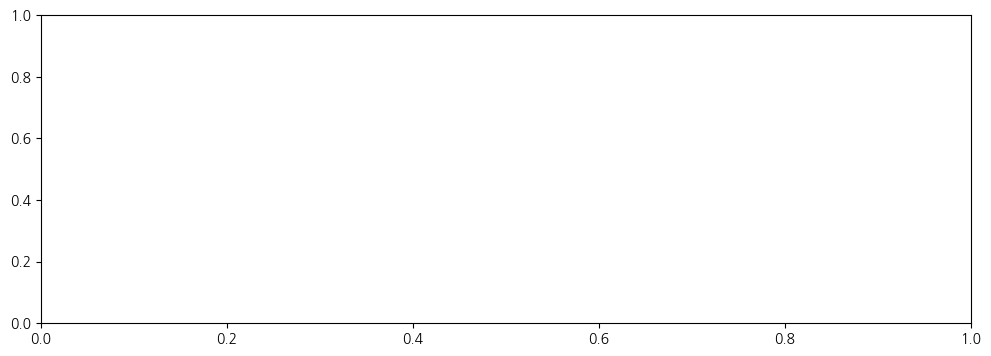

In [63]:
fig, axes = plt.subplots(figsize=(12, 4))

# 멀티 인덱스의 각 인덱스 이름 변경
quarterly_close_renamed = quarterly_close.rename_axis(index=['year', 'quarter'])
quarterly_close_df = quarterly_close_renamed.reset_index()
print(type(quarterly_close_df))

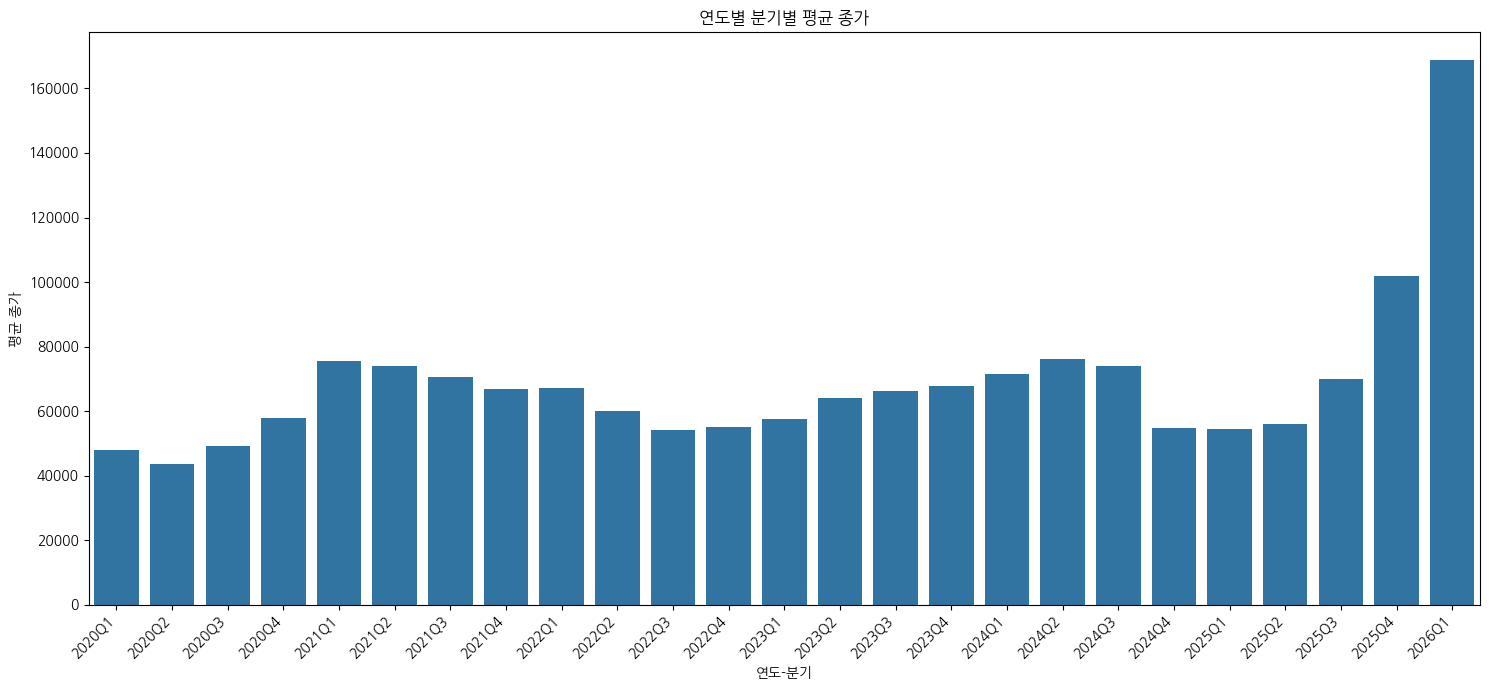

In [67]:
quarterly_close_df['quarter_label'] = quarterly_close_df['year'].astype(str) + 'Q' + quarterly_close_df['quarter'].astype(str)

plt.figure(figsize=(15, 7))
sns.barplot(x='quarter_label', y='Close', data=quarterly_close_df)
plt.title('연도별 분기별 평균 종가')
plt.xlabel('연도-분기')
plt.ylabel('평균 종가')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [68]:
df_f.index

DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2026-03-06', '2026-03-09', '2026-03-10', '2026-03-11',
               '2026-03-12', '2026-03-13', '2026-03-16', '2026-03-17',
               '2026-03-18', '2026-03-19'],
              dtype='datetime64[ns]', name='Date', length=1521, freq=None)

In [74]:
df_2025 = df_f.loc['2025']
df_2025.shape
df_2025.head()

Price,Open,High,Low,Close,Volume,year,month,day,weekday,quarter,dayofyear,weekday_name,days_elapsed,days_int,trading_day
Date,,,,,,,,,,,,,,,
2025-01-02,51587.303093,52468.300679,51195.748610,52272.523438,16630538,2025,1,2,3,1,2,목,1827 days,1827,1229
2025-01-03,51685.196002,53936.634464,51685.196002,53251.414062,19318046,2025,1,3,4,1,3,금,1828 days,1828,1230
2025-01-06,53251.416592,55013.411994,53153.527959,54719.746094,19034284,2025,1,6,0,1,6,월,1831 days,1831,1231
2025-01-07,55600.741595,56090.184743,54230.300781,54230.300781,17030235,2025,1,7,1,1,7,화,1832 days,1832,1232
2025-01-08,53642.971640,56285.964769,53545.083006,56090.187500,26593553,2025,1,8,2,1,8,수,1833 days,1833,1233


In [75]:
df_2025_12 = df_f.loc['2025-12']
df_2025_12.shape
df_2025_12.head()

Price,Open,High,Low,Close,Volume,year,month,day,weekday,quarter,dayofyear,weekday_name,days_elapsed,days_int,trading_day
Date,,,,,,,,,,,,,,,
2025-12-01,101506.562035,102302.691933,99416.721052,100312.367188,10905526,2025,12,1,0,4,335,월,2160 days,2160,1449
2025-12-02,100710.431848,102999.305300,100511.399374,102899.789062,13649487,2025,12,2,1,4,336,화,2161 days,2161,1450
2025-12-03,104193.501226,104989.631130,103496.887560,103994.468750,14697927,2025,12,3,2,4,337,수,2162 days,2162,1451
2025-12-04,103397.367686,104591.562500,102700.754044,104591.562500,11931145,2025,12,4,3,4,338,목,2163 days,2163,1452
2025-12-05,104790.598197,107875.601562,104093.984534,107875.601562,19755571,2025,12,5,4,4,339,금,2164 days,2164,1453


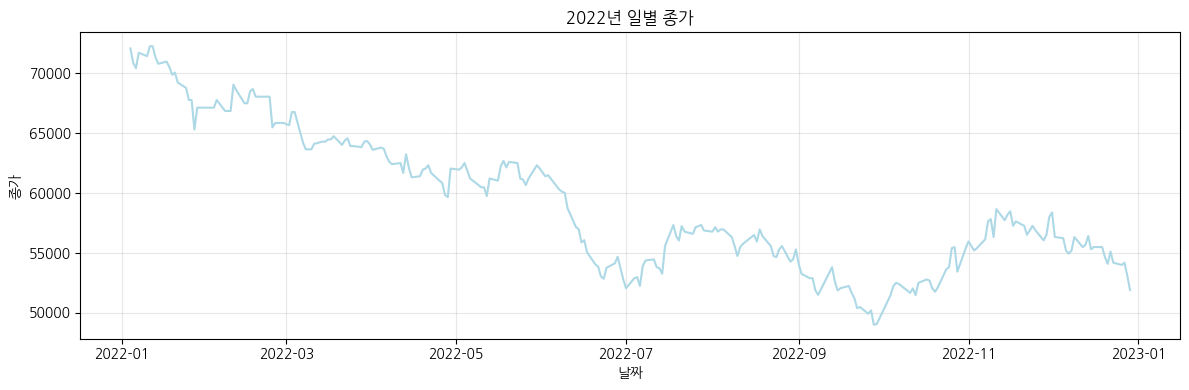

In [79]:
df_2022 = df_f.loc['2022']

fig, axes = plt.subplots(figsize=(12, 4))
sns.lineplot(x=df_2022.index, y='Close', data=df_2022, ax=axes, color='lightblue', linewidth=1.5)
axes.set_title('2022년 일별 종가')
axes.set_xlabel('날짜')
axes.set_ylabel('종가')
axes.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [84]:
mask = (df_f.index.year == 2026) & (df_f.index.month == 2)
df_2026_2 = df_f[mask]
df_2026_2.shape

(17, 15)

In [86]:
df_td = df_f.copy()
df_td['days_elapsed'] = df_td.index - base_date
df_td = df_td.set_index('days_elapsed')
df_td.head()

Price,Open,High,Low,Close,Volume,year,month,day,weekday,quarter,dayofyear,weekday_name,days_int,trading_day
days_elapsed,,,,,,,,,,,,,,
0 days,47728.888523,48158.878510,47298.898537,47470.894531,12993228,2020,1,2,3,1,2,목,0,0
1 days,48158.884572,48674.872621,47212.906482,47728.894531,15422255,2020,1,3,4,1,3,금,1,1
4 days,47212.906482,47814.892539,46954.912458,47728.894531,10278951,2020,1,6,0,1,6,월,4,2
5 days,47900.884815,48502.870800,47814.886817,47986.882812,10009778,2020,1,7,1,1,7,화,5,3
6 days,48330.883019,49362.859169,48072.888981,48846.871094,23501171,2020,1,8,2,1,8,수,6,4


In [91]:
df_2022_close = df_f.loc['2022', 'Close']
print(f'원본 거래 일 수: {len(df_2022_close)}')
display(df_2022_close)

full_range = pd.date_range(start='2022-01-01', end='2022-12-30', freq='D')
df_2022_full = df_f.reindex(full_range)

원본 거래 일 수: 244


,Close
Date,
2022-01-04,72089.250000
2022-01-05,70898.445312
2022-01-06,70440.437500
2022-01-07,71722.835938
2022-01-10,71448.046875
...,...
2022-12-23,54191.636719
2022-12-26,54005.089844
2022-12-27,54191.636719


In [94]:
df_s = df_f[['Close']].copy()
df_s['Close_lag1'] = df_s['Close'].shift(1)
df_s['Close_lag5'] = df_s['Close'].shift(5)
df_s['Close_lead1'] = df_s['Close'].shift(-1) # 위로 1칸 이동

print(f'=== shift 결과 ===\n{df_s.head()}')

=== shift 결과 ===
Price              Close    Close_lag1  Close_lag5   Close_lead1
Date                                                            
2020-01-02  47470.894531           NaN         NaN  47728.894531
2020-01-03  47728.894531  47470.894531         NaN  47728.894531
2020-01-06  47728.894531  47728.894531         NaN  47986.882812
2020-01-07  47986.882812  47728.894531         NaN  48846.871094
2020-01-08  48846.871094  47986.882812         NaN  50394.843750


In [96]:
# 일간 수익률 계산
df['daily_return'] = df['Close'] / df['Close'].shift(1) - 1
df['daily_return'] = df['Close'].pct_change()

In [97]:
df_ma = df_f[['Close']].copy()
df_ma['MA5'] = df_ma['Close'].rolling(5).mean()
df_ma['MA20'] = df_ma['Close'].rolling(20).mean()
df_ma['MA60'] = df_ma['Close'].rolling(60).mean()

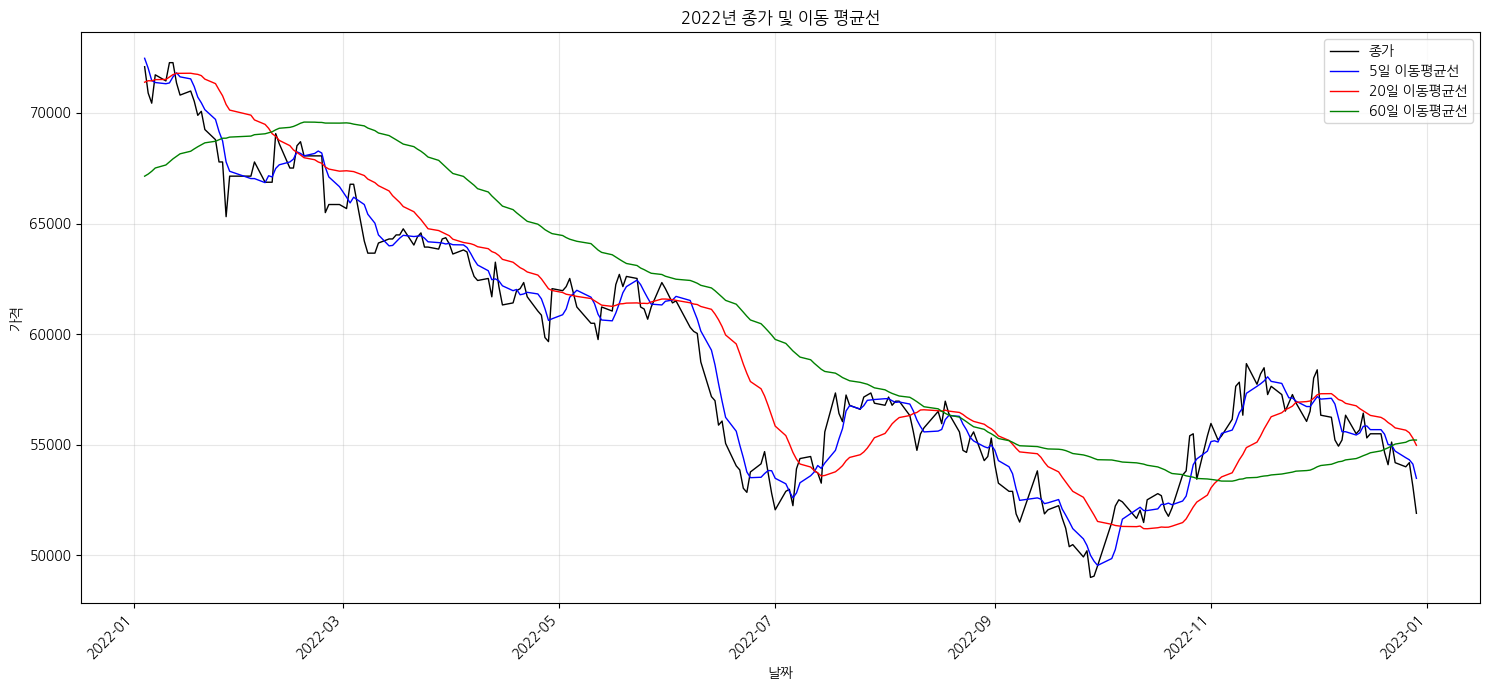

In [98]:
df_ma_2022 = df_ma.loc['2022']

plt.figure(figsize=(15, 7))
plt.plot(df_ma_2022.index, df_ma_2022['Close'], label='종가', color='black', linewidth=1)
plt.plot(df_ma_2022.index, df_ma_2022['MA5'], label='5일 이동평균선', color='blue', linewidth=1)
plt.plot(df_ma_2022.index, df_ma_2022['MA20'], label='20일 이동평균선', color='red', linewidth=1)
plt.plot(df_ma_2022.index, df_ma_2022['MA60'], label='60일 이동평균선', color='green', linewidth=1)

plt.title('2022년 종가 및 이동 평균선')
plt.xlabel('날짜')
plt.ylabel('가격')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [99]:
# 월별 종가 평균
monthly_close = df_f['Close'].resample('M').mean()
print(monthly_close)

Date
2020-01-31     50579.728906
2020-02-29     50811.922266
2020-03-31     43311.952415
2020-04-30     42489.132227
2020-05-31     42536.781044
                  ...      
2025-11-30    100212.851953
2025-12-31    108252.992932
2026-01-31    146542.857143
2026-02-28    180929.411765
2026-03-31    189346.153846
Freq: ME, Name: Close, Length: 75, dtype: float64


In [100]:
# 연도별 총 거래량
yearly_volume = df_f['Volume'].resample('A').sum()
print(yearly_volume)

Date
2020-12-31    5393337715
2021-12-31    4658484662
2022-12-31    3390581493
2023-12-31    2994215134
2024-12-31    5293964801
2025-12-31    4644967393
2026-12-31    1641193549
Freq: YE-DEC, Name: Volume, dtype: int64


In [106]:
# 월별 데이터
monthly_close = df['Close'].resample('M').mean()
print(monthly_close)
# 일별 업샘플링 후
daily_from_monthly = monthly_close.resample('D').asfreq()
print(daily_from_monthly)

Ticker          005930.KS
Date                     
2020-01-31   50579.728906
2020-02-29   50811.922266
2020-03-31   43311.952415
2020-04-30   42489.132227
2020-05-31   42536.781044
...                   ...
2025-11-30  100212.851953
2025-12-31  108252.992932
2026-01-31  146542.857143
2026-02-28  180929.411765
2026-03-31  189346.153846

[75 rows x 1 columns]
Ticker          005930.KS
Date                     
2020-01-31   50579.728906
2020-02-01            NaN
2020-02-02            NaN
2020-02-03            NaN
2020-02-04            NaN
...                   ...
2026-03-27            NaN
2026-03-28            NaN
2026-03-29            NaN
2026-03-30            NaN
2026-03-31  189346.153846

[2252 rows x 1 columns]


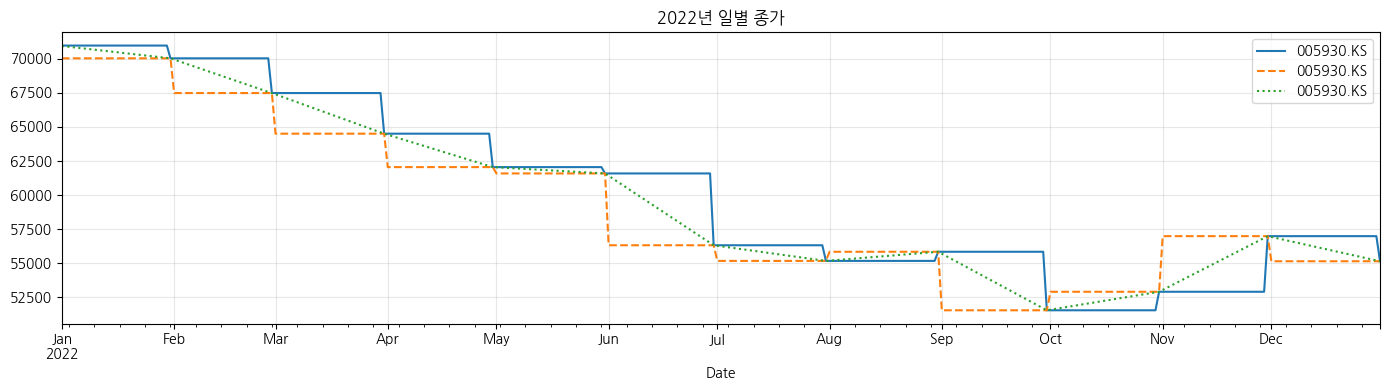

In [110]:
daily_ffill = daily_from_monthly.ffill()
daily_bfill = daily_from_monthly.bfill()
daily_interp = daily_from_monthly.interpolate()

fig, axes = plt.subplots(figsize=(14, 4))
daily_ffill.loc['2022'].plot(ax=axes, label='ffill', linewidth=1.5)
daily_bfill.loc['2022'].plot(ax=axes, label='bfill',  linewidth=1.5, linestyle='--')
daily_interp.loc['2022'].plot(ax=axes, label='interpolate', linewidth=1.5, linestyle=':')
axes.set_title('2022년 일별 종가')
axes.legend()
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

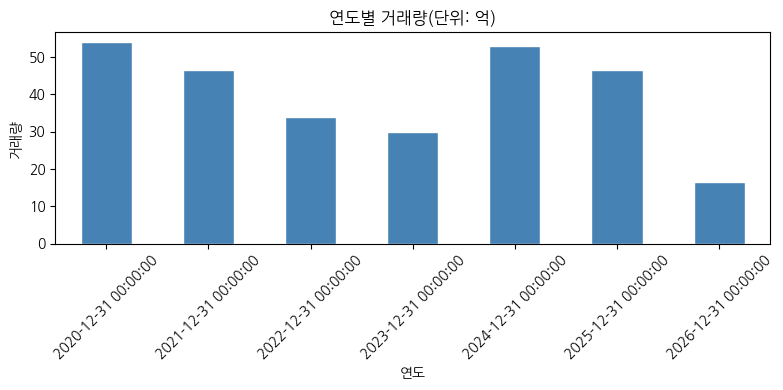

In [114]:
yearly_vol = df_f['Volume'].resample('A').sum() / 1e8
fig, axes = plt.subplots(figsize=(8,4))
yearly_vol.plot(kind='bar', ax=axes, color='steelblue', edgecolor='white')
axes.set_title('연도별 거래량(단위: 억)')
axes.set_xlabel('연도')
axes.set_ylabel('거래량')
axes.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

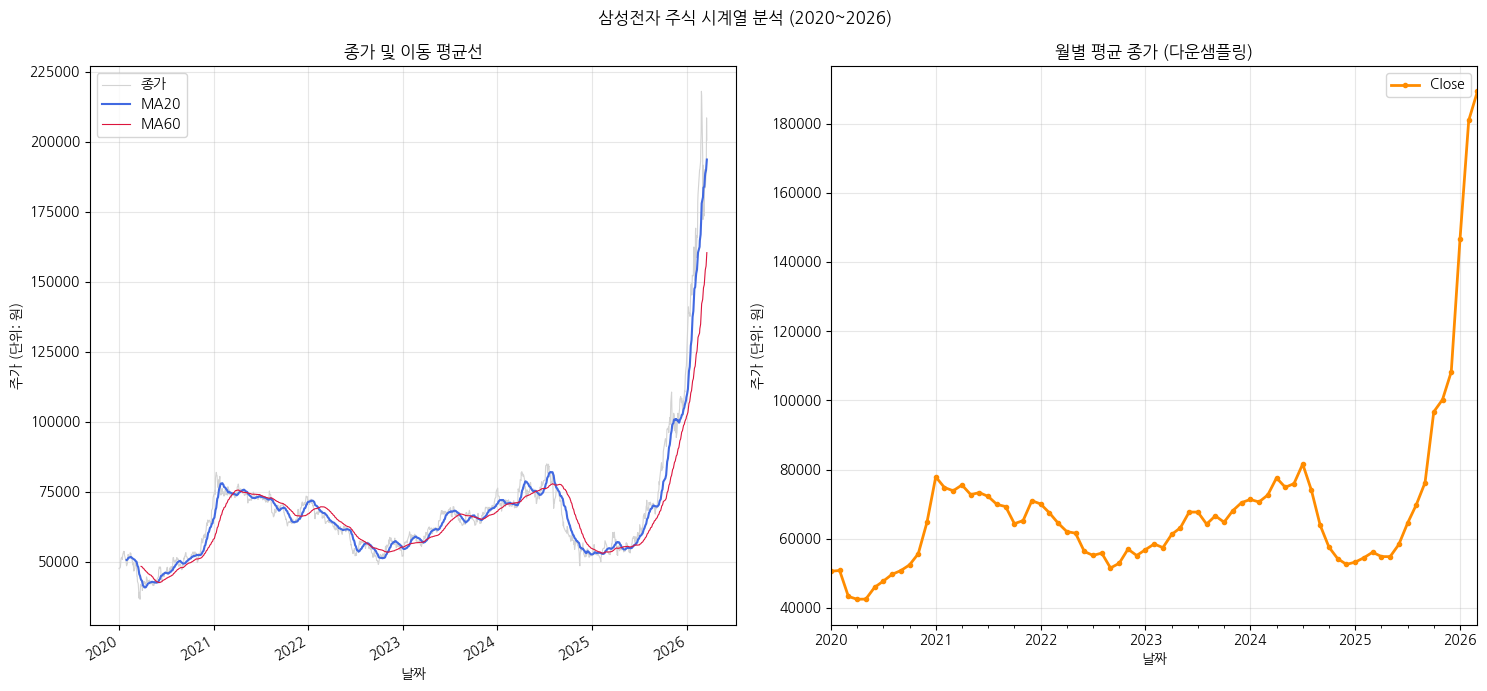

In [125]:
# 삼성전자 주식 시계열 대시보드
df_all = df_f.copy()

df_all['MA20'] = df_all['Close'].rolling(20).mean() # 20일 이동 평균 (20일치 종가의 평균)
df_all['MA60'] = df_all['Close'].rolling(60).mean() # 60일 이동 평균 (60일치 종가의 평균)
df_all['Return'] = df_all['Close'].pct_change() # 일간 수익률 계산 (전일 대비 종가 변화율)
df_all['year'] = df_all.index.year
df_all['month'] = df_all.index.month
monthly_avg = df_all['Close'].resample('MS').mean()

# 대시보드 레이아웃
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('삼성전자 주식 시계열 분석 (2020~2026)')
ax1 = axes[0]
df_all['Close'].plot(ax=ax1, color='lightgray', linewidth=0.8, label='종가')
df_all['MA20'].plot(ax=ax1, color='royalblue', linewidth=1.5, label='MA20')
df_all['MA60'].plot(ax=ax1, color='crimson', linewidth=0.8, label='MA60')
ax1.set_title('종가 및 이동 평균선')
ax1.set_ylabel('주가 (단위: 원)')
ax1.set_xlabel('날짜')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
monthly_avg.plot(ax=ax2, color='darkorange', linewidth=2, marker='o', markersize=3)
ax2.set_title('월별 평균 종가 (다운샘플링)')
ax2.set_ylabel('주가 (단위: 원)')
ax2.set_xlabel('날짜')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()